In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

In [15]:
df = pd.read_csv('Merged_SoilMoisture_Data.csv')

In [16]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Points: {df['Point_ID'].nunique()}  |  Dates: {df['Date'].nunique()}")

Loaded: 401 rows × 17 columns
Points: 100  |  Dates: 22


In [17]:
df.isnull().sum()

Point_ID                0
Date                    0
latitude                0
longitude               0
Elevation_m             0
Slope                   0
Aspect                  0
Roughness               0
VV_500m                 1
VH_500m                 2
Angle_500m              1
CR=VH/VV                0
RVI                     0
RPI=VV/VH               0
NDPI=(VV-VH)/(VV+VH)    0
MPI                     0
Observed_SM             0
dtype: int64

In [18]:
import numpy as np
import pandas as pd

# Replace all 0 values in the entire dataset with NaN
df.replace(0, np.nan, inplace=True)

# Check how many NaN values are present now
print(df.isnull().sum())

Point_ID                 2
Date                     0
latitude                 0
longitude                0
Elevation_m              0
Slope                   19
Aspect                   2
Roughness               19
VV_500m                  1
VH_500m                  2
Angle_500m               1
CR=VH/VV                 0
RVI                      0
RPI=VV/VH                0
NDPI=(VV-VH)/(VV+VH)     1
MPI                      0
Observed_SM              0
dtype: int64


In [19]:
df.columns

Index(['Point_ID', 'Date', 'latitude', 'longitude', 'Elevation_m', 'Slope',
       'Aspect', 'Roughness', 'VV_500m', 'VH_500m', 'Angle_500m', 'CR=VH/VV',
       'RVI', 'RPI=VV/VH', 'NDPI=(VV-VH)/(VV+VH)', 'MPI', 'Observed_SM'],
      dtype='object')

In [20]:
def engineer_features(df):
    df = df.copy()
 
    #  Temporal features (captures seasonal SM cycle) 
    df['month']     = df['Date'].dt.month
    df['doy']       = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
 
    #  Fix 3 missing SAR values (spatial median per point) 
    for col in ['Slope','Aspect', 'Roughness','VV_500m', 'VH_500m', 'Angle_500m', 'NDPI=(VV-VH)/(VV+VH)']:
        null_mask = df[col].isnull()
        if null_mask.sum() > 0:
            fill = df.groupby('Point_ID')[col].transform('mean')
            df.loc[null_mask, col] = fill[null_mask]
 
    #  SAR physics features 
    df['VV_linear']  = 10 ** (df['VV_500m'] / 10)   # dB → linear
    df['VH_linear']  = 10 ** (df['VH_500m'] / 10)
    df['VV_VH_diff'] = df['VV_500m'] - df['VH_500m']
 
    #  Terrain interaction features 
    df['slope_elev']  = df['Elevation_m'] / (df['Slope'] + 0.1)
    df['rough_slope'] = df['Roughness'] * df['Slope']
 
    df['VV_x_season'] = df['VV_linear'] * df['month_sin']
    df['VH_x_season'] = df['VH_linear'] * df['month_sin']
    df['VV_x_cos']    = df['VV_linear'] * df['month_cos']
    df['VH_x_cos']    = df['VH_linear'] * df['month_cos']
 
    return df
 
df = engineer_features(df)
 
FEATURES = [
    # SAR backscatter (raw + linear)
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    # Polarimetric indices
    'CR=VH/VV', 'RVI', 'RPI=VV/VH', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    # Terrain
    'Elevation_m', 'Slope', 'Aspect', 'Roughness',
    'slope_elev', 'rough_slope',
    # Temporal
    'VV_x_season',
    'VH_x_season',
    'VV_x_cos',   
    'VH_x_cos'    
 
    
]
 
X = df[FEATURES].copy()
y = df['Observed_SM'].copy()

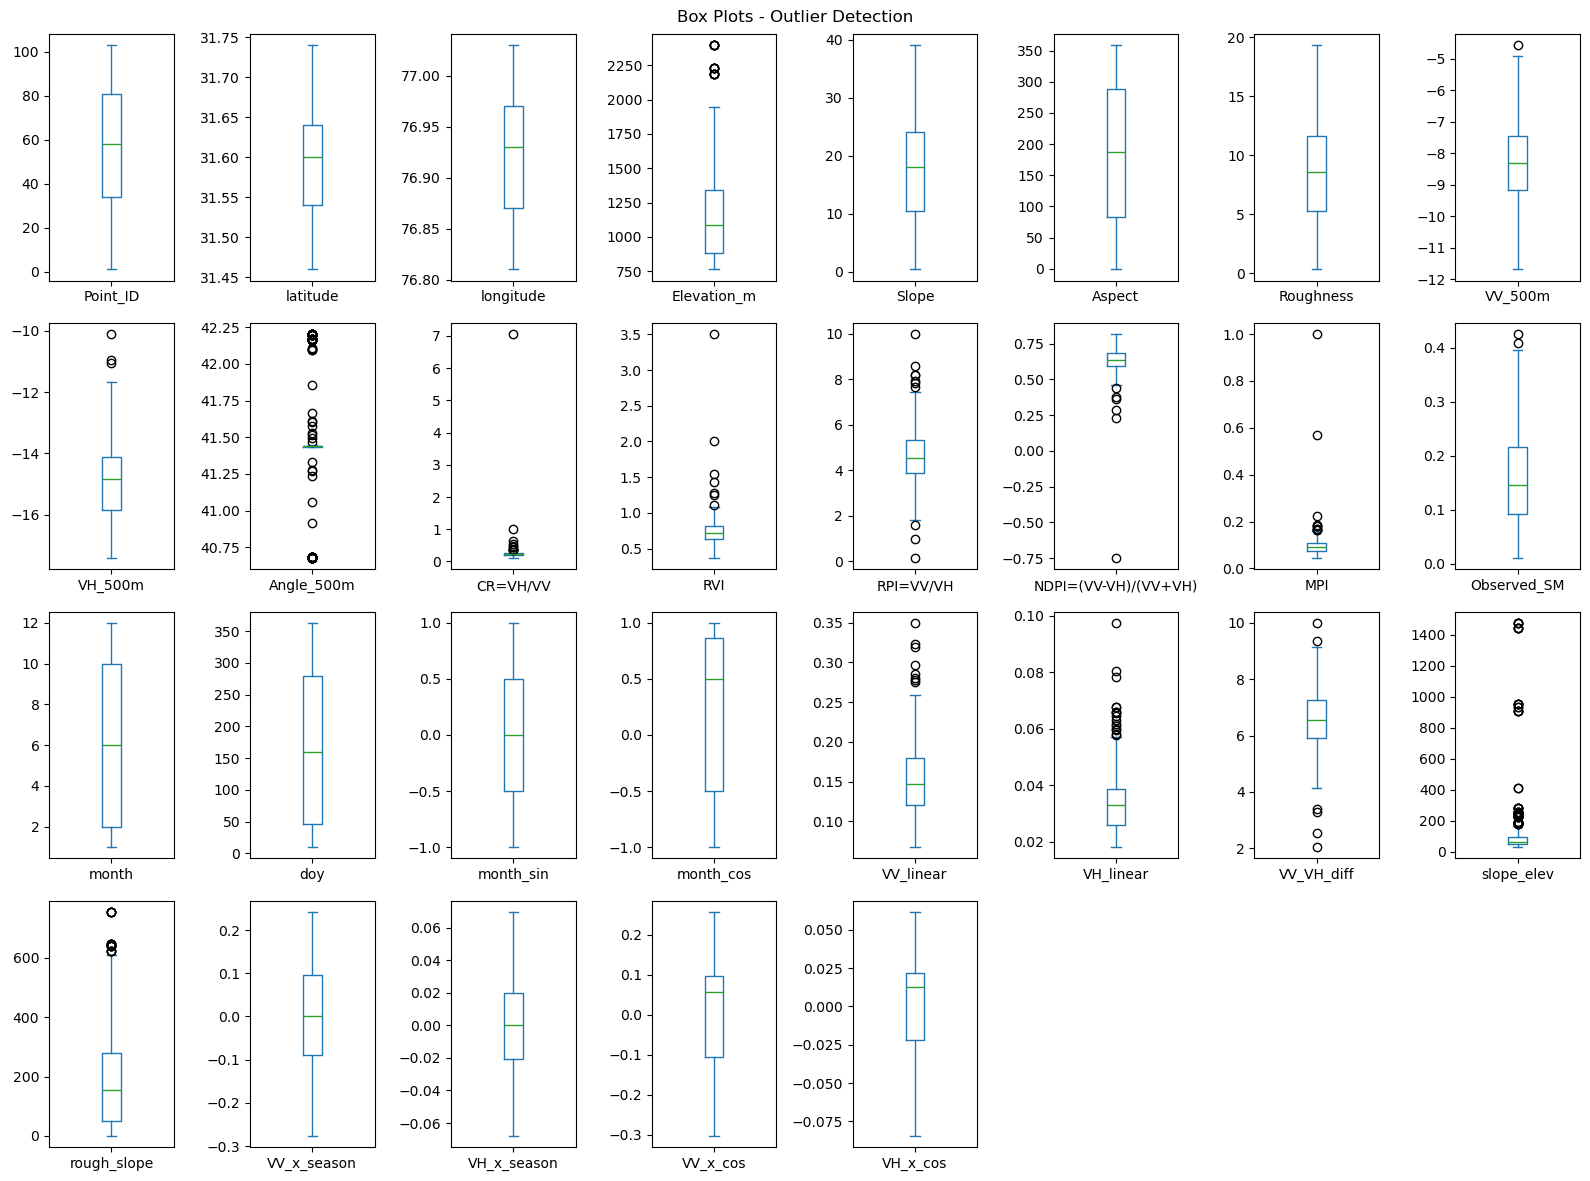

In [8]:
df.plot(kind='box', subplots=True, layout=(4,8), figsize=(16, 12), sharey=False)
plt.suptitle('Box Plots - Outlier Detection')
plt.tight_layout()
plt.show()

In [9]:

numeric_cols = df.select_dtypes(include='number').columns
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary[col] = outlier_mask.sum()

# Print summary
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

Point_ID: 0 outliers
latitude: 0 outliers
longitude: 0 outliers
Elevation_m: 15 outliers
Slope: 0 outliers
Aspect: 0 outliers
Roughness: 0 outliers
VV_500m: 1 outliers
VH_500m: 3 outliers
Angle_500m: 93 outliers
CR=VH/VV: 10 outliers
RVI: 7 outliers
RPI=VV/VH: 10 outliers
NDPI=(VV-VH)/(VV+VH): 6 outliers
MPI: 10 outliers
Observed_SM: 2 outliers
month: 0 outliers
doy: 0 outliers
month_sin: 0 outliers
month_cos: 0 outliers
VV_linear: 8 outliers
VH_linear: 16 outliers
VV_VH_diff: 6 outliers
slope_elev: 62 outliers
rough_slope: 18 outliers
VV_x_season: 0 outliers
VH_x_season: 0 outliers
VV_x_cos: 0 outliers
VH_x_cos: 0 outliers


In [22]:
exclude = ['Point_ID', 'Angle_500m','slope_elev']
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Clipping done.")

Clipping done.


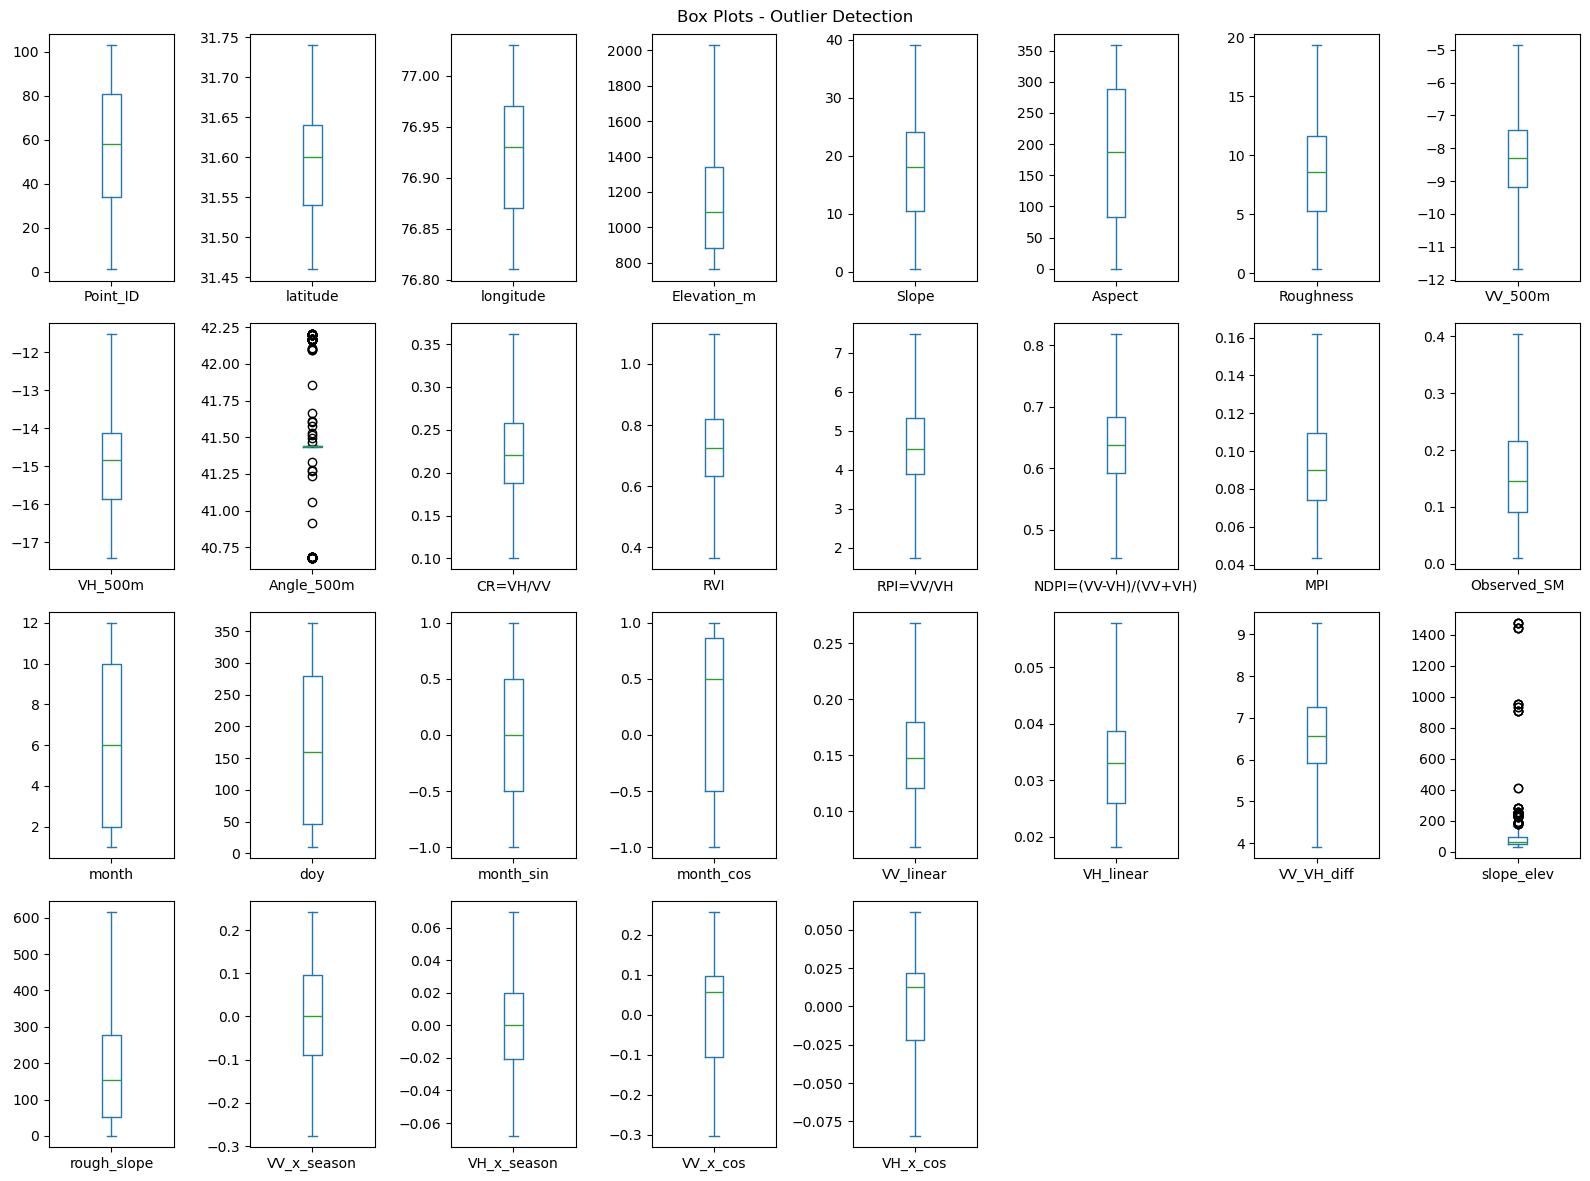

In [12]:
df.plot(kind='box', subplots=True, layout=(4,8), figsize=(16, 12), sharey=False)
plt.suptitle('Box Plots - Outlier Detection')
plt.tight_layout()
plt.show()

In [21]:
#without clipping

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[FEATURES].copy()
y = df['Observed_SM'].copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # 0.2 instead of 0.25 — more training data
)

# Scale
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Tighter grid tuned for small datasets
param_grid = {
    'n_estimators':     [50,100,200,300,500],
    'max_depth':        [2,4,8],
    'min_samples_leaf': [4,6,8,10, 12],   # higher — prevents overfitting on small data
    'max_features':     ['sqrt', 0.5, 0.7,1],
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = rf,
    param_grid = param_grid,
    cv         = 5,           # 5-fold instead of 10 — more data per fold
    scoring    = 'r2',
    verbose    = 1,
    n_jobs     = -1
)

grid_search.fit(X_train_sc, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2     :", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_

# CV
cv_scores = cross_val_score(best_rf, X_train_sc, y_train, cv=5, scoring='r2')
print(f"\nCV R2 Scores : {cv_scores.round(4)}")
print(f"CV Mean R2   : {cv_scores.mean():.4f}")
print(f"CV Std R2    : {cv_scores.std():.4f}")

# Predictions
y_pred_train = best_rf.predict(X_train_sc)
y_pred_test  = best_rf.predict(X_test_sc)

# Evaluation
def evaluate(y_true, y_pred, split_name):
    r      = np.corrcoef(y_true, y_pred)[0, 1]
    r2     = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    bias   = np.mean(y_pred - y_true)
    ubrmse = np.sqrt(np.mean(((y_pred - y_pred.mean()) - (y_true - y_true.mean())) ** 2))

    print(f"\n── {split_name} ──")
    print(f"  R      : {r:.4f}")
    print(f"  R2     : {r2:.4f}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  ubRMSE : {ubrmse:.4f}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  Bias   : {bias:.4f}")

evaluate(y_train, y_pred_train, "Training")
evaluate(y_test,  y_pred_test,  "Testing")

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best Parameters: {'max_depth': 8, 'max_features': 0.7, 'min_samples_leaf': 6, 'n_estimators': 300}
Best CV R2     : 0.3119

CV R2 Scores : [0.2491 0.4243 0.2706 0.3918 0.2236]
CV Mean R2   : 0.3119
CV Std R2    : 0.0806

── Training ──
  R      : 0.8519
  R2     : 0.6696
  RMSE   : 0.0470
  ubRMSE : 0.0470
  MAE    : 0.0370
  Bias   : 0.0000

── Testing ──
  R      : 0.5642
  R2     : 0.3130
  RMSE   : 0.0671
  ubRMSE : 0.0669
  MAE    : 0.0531
  Bias   : 0.0055


In [23]:
#with clipping

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[FEATURES].copy()
y = df['Observed_SM'].copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # 0.2 instead of 0.25 — more training data
)

# Scale
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Tighter grid tuned for small datasets
param_grid = {
    'n_estimators':     [50,100,200,300,500],
    'max_depth':        [2,4,8],
    'min_samples_leaf': [4,6,8,10, 12],   # higher — prevents overfitting on small data
    'max_features':     ['sqrt', 0.5, 0.7,1],
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = rf,
    param_grid = param_grid,
    cv         = 5,           # 5-fold instead of 10 — more data per fold
    scoring    = 'r2',
    verbose    = 1,
    n_jobs     = -1
)

grid_search.fit(X_train_sc, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2     :", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_

# CV
cv_scores = cross_val_score(best_rf, X_train_sc, y_train, cv=5, scoring='r2')
print(f"\nCV R2 Scores : {cv_scores.round(4)}")
print(f"CV Mean R2   : {cv_scores.mean():.4f}")
print(f"CV Std R2    : {cv_scores.std():.4f}")

# Predictions
y_pred_train = best_rf.predict(X_train_sc)
y_pred_test  = best_rf.predict(X_test_sc)

# Evaluation
def evaluate(y_true, y_pred, split_name):
    r      = np.corrcoef(y_true, y_pred)[0, 1]
    r2     = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    bias   = np.mean(y_pred - y_true)
    ubrmse = np.sqrt(np.mean(((y_pred - y_pred.mean()) - (y_true - y_true.mean())) ** 2))

    print(f"\n── {split_name} ──")
    print(f"  R      : {r:.4f}")
    print(f"  R2     : {r2:.4f}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  ubRMSE : {ubrmse:.4f}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  Bias   : {bias:.4f}")

evaluate(y_train, y_pred_train, "Training")
evaluate(y_test,  y_pred_test,  "Testing")

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best Parameters: {'max_depth': 8, 'max_features': 0.7, 'min_samples_leaf': 6, 'n_estimators': 300}
Best CV R2     : 0.3121

CV R2 Scores : [0.2487 0.4246 0.2712 0.3925 0.2237]
CV Mean R2   : 0.3121
CV Std R2    : 0.0808

── Training ──
  R      : 0.8521
  R2     : 0.6698
  RMSE   : 0.0470
  ubRMSE : 0.0470
  MAE    : 0.0370
  Bias   : 0.0000

── Testing ──
  R      : 0.5649
  R2     : 0.3129
  RMSE   : 0.0664
  ubRMSE : 0.0661
  MAE    : 0.0528
  Bias   : 0.0057
